# **Problema 1 – Clasificación: Detección de Fatiga Muscular en Ciclismo**
## Integrantes
* Antonia Muñoz Jiménez
* Luis Moreno Gutiérrez
* Juan Carlos Fernández Vanoy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from datasets import load_dataset

# **Sección 1 - Análisis Preliminar del Problema**
**a.** Preprocese el target estableciendo únicamente 2 etiquetas:

`0` = Condición normal

`1` = Desgaste muscular

Para lo anterior, las etiquetas estimadas en 2 se cambiaran por 1

**b.** Clasifique las características presentes en el dataset en tipos de variables (numéricas, categóricas, binarias, ordinales, etc.).


In [ ]:
# -------------------------------------------------------
# 1. Carga del dataset
# -------------------------------------------------------
dataset = load_dataset("YominE/Muscle_Fatigue_Cycling")
df = dataset['train'].to_pandas()
# (filas, columnas) util para entender el tamaño del dataset
print(df.shape)
print(df.head())

(3002137, 10)
    Time  Right Rectus femoris  Left Gluteus maximus  \
0  0.000             -0.000264             -0.000015   
1  0.001             -0.001002             -0.000045   
2  0.002             -0.002173             -0.000034   
3  0.003             -0.002676              0.000185   
4  0.004             -0.000844              0.000785   

   Left Gastrocnemius medialis  Left Semitendinosus  \
0                     0.000344             0.000108   
1                     0.001342             0.000429   
2                     0.002944             0.001133   
3                     0.003504             0.002319   
4                     0.000426             0.003950   

   Left Biceps femoris caput longus  Right Vastus medialis  \
0                          0.000182               0.000401   
1                          0.000712               0.002234   
2                          0.001692               0.007634   
3                          0.002820               0.017656   
4       

In [ ]:
# -------------------------------------------------------
# 1. Exploración inicial (columnas, target)
# -------------------------------------------------------
print("Columnas:", df.columns.tolist())
print("\nValores unicos del target:", df['Target'].unique())
print("\nConteo por clase:")
print(df['Target'].value_counts())

Columnas: ['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target']

Valores unicos del target: [0 1 2]

Conteo por clase:
Target
0    2127600
1     631200
2     243337
Name: count, dtype: int64


In [ ]:

# -------------------------------------------------------
# 1. Preprocesamiento del target (fusión clase 2→1)
# -------------------------------------------------------

# Fusionar etiquetas 1 y 2 en una sola (desgaste muscular)
df['Target'] = df['Target'].replace(2, 1)

print("Valores unicos del target despues del preprocesamiento:", df['Target'].unique())
print("\nConteo por clase:")
print(df['Target'].value_counts())

# Guardar nombres de los 8 canales
channels = [
    'Right Rectus femoris',
    'Left Gluteus maximus',
    'Left Gastrocnemius medialis',
    'Left Semitendinosus',
    'Left Biceps femoris caput longus',
    'Right Vastus medialis',
    'Right Tibialis anterior',
    'Left Gastrocnemius lateralis'
]

Valores unicos del target despues del preprocesamiento: [0 1]

Conteo por clase:
Target
0    2127600
1     874537
Name: count, dtype: int64


In [ ]:
# -------------------------------------------------------
# 1. Clasificación de tipos de variables + estadísticos descriptivos
# -------------------------------------------------------

# Clasificamos cada variable del dataset segun su tipo estadístico
print("--- TIPOS DE VARIABLES ---\n")
print("Variable de tiempo:")
print(f"  - Time: Numerica continua (segundos)\n")

print("Variables de entrada (señales EMG):")
for ch in channels:
    print(f"  - {ch}: Numerica continua (amplitud en mV)")

print("\nVariable objetivo:")
print("  - Target: Binaria categorica (0 = normal, 1 = desgaste)")

print("\n--- ESTADISTICOS DESCRIPTIVOS ---\n")
print(df[channels].describe().round(4)) ## describe() calcula automáticamente count, mean, std, min, 25%, 50%, 75%, max

--- TIPOS DE VARIABLES ---

Variable de tiempo:
  - Time: Numerica continua (segundos)

Variables de entrada (señales EMG):
  - Right Rectus femoris: Numerica continua (amplitud en mV)
  - Left Gluteus maximus: Numerica continua (amplitud en mV)
  - Left Gastrocnemius medialis: Numerica continua (amplitud en mV)
  - Left Semitendinosus: Numerica continua (amplitud en mV)
  - Left Biceps femoris caput longus: Numerica continua (amplitud en mV)
  - Right Vastus medialis: Numerica continua (amplitud en mV)
  - Right Tibialis anterior: Numerica continua (amplitud en mV)
  - Left Gastrocnemius lateralis: Numerica continua (amplitud en mV)

Variable objetivo:
  - Target: Binaria categorica (0 = normal, 1 = desgaste)

--- ESTADISTICOS DESCRIPTIVOS ---

       Right Rectus femoris  Left Gluteus maximus  \
count          3.002137e+06          3.002137e+06   
mean           0.000000e+00         -0.000000e+00   
std            4.320000e-02          2.130000e-02   
min           -8.433000e-01     

# **Sección 2 - Extracción de Características (Feature Engineering)**
**a.** Diseñe un algoritmo que tome ventanas de 1 segundo sobre los 8 canales de señal, teniendo en cuenta la frecuencia de muestreo determinada previamente.

**b.** Extraiga **mínimo 4 características** por ventana por canal, combinando características en el **dominio del tiempo** (ej. valor RMS, varianza, cruce por cero, pendiente media de la señal) y en el **dominio de la frecuencia** (ej. frecuencia mediana, frecuencia media, potencia espectral). Estas características conformarán la nueva base de datos. Para la nueva base de datos no tenga en cuenta la variable tiempo, ya que su dependencia lineal con el target sobresimplificaria el problema.

**c.** Documente y justifique cada característica seleccionada en términos de su relevancia.

---
# **Sección 3 - Análisis Exploratorio de Datos (EDA)**
Realice un EDA completo sobre la nueva base de datos de características:

*   Distribuciones de variables y estadísticos descriptivos.
*   Correlaciones entre características.
*   Relación entre características y el target (boxplots por clase, separabilidad).
*   Análisis de balance de clases.





Cada gráfico o estadística debe ir acompañado de una interpretación detallada que explique qué información aporta al problema de clasificación.

Utilice librerías como `pandas`, `numpy`, `matplotlib` y `seaborn`.

**a.** Grafique una porción de las señales en el tiempo y haga una identificación inicial de los datos. Basado en la informacion disponible, cuales son sus conclusiones acerca de este dataset?


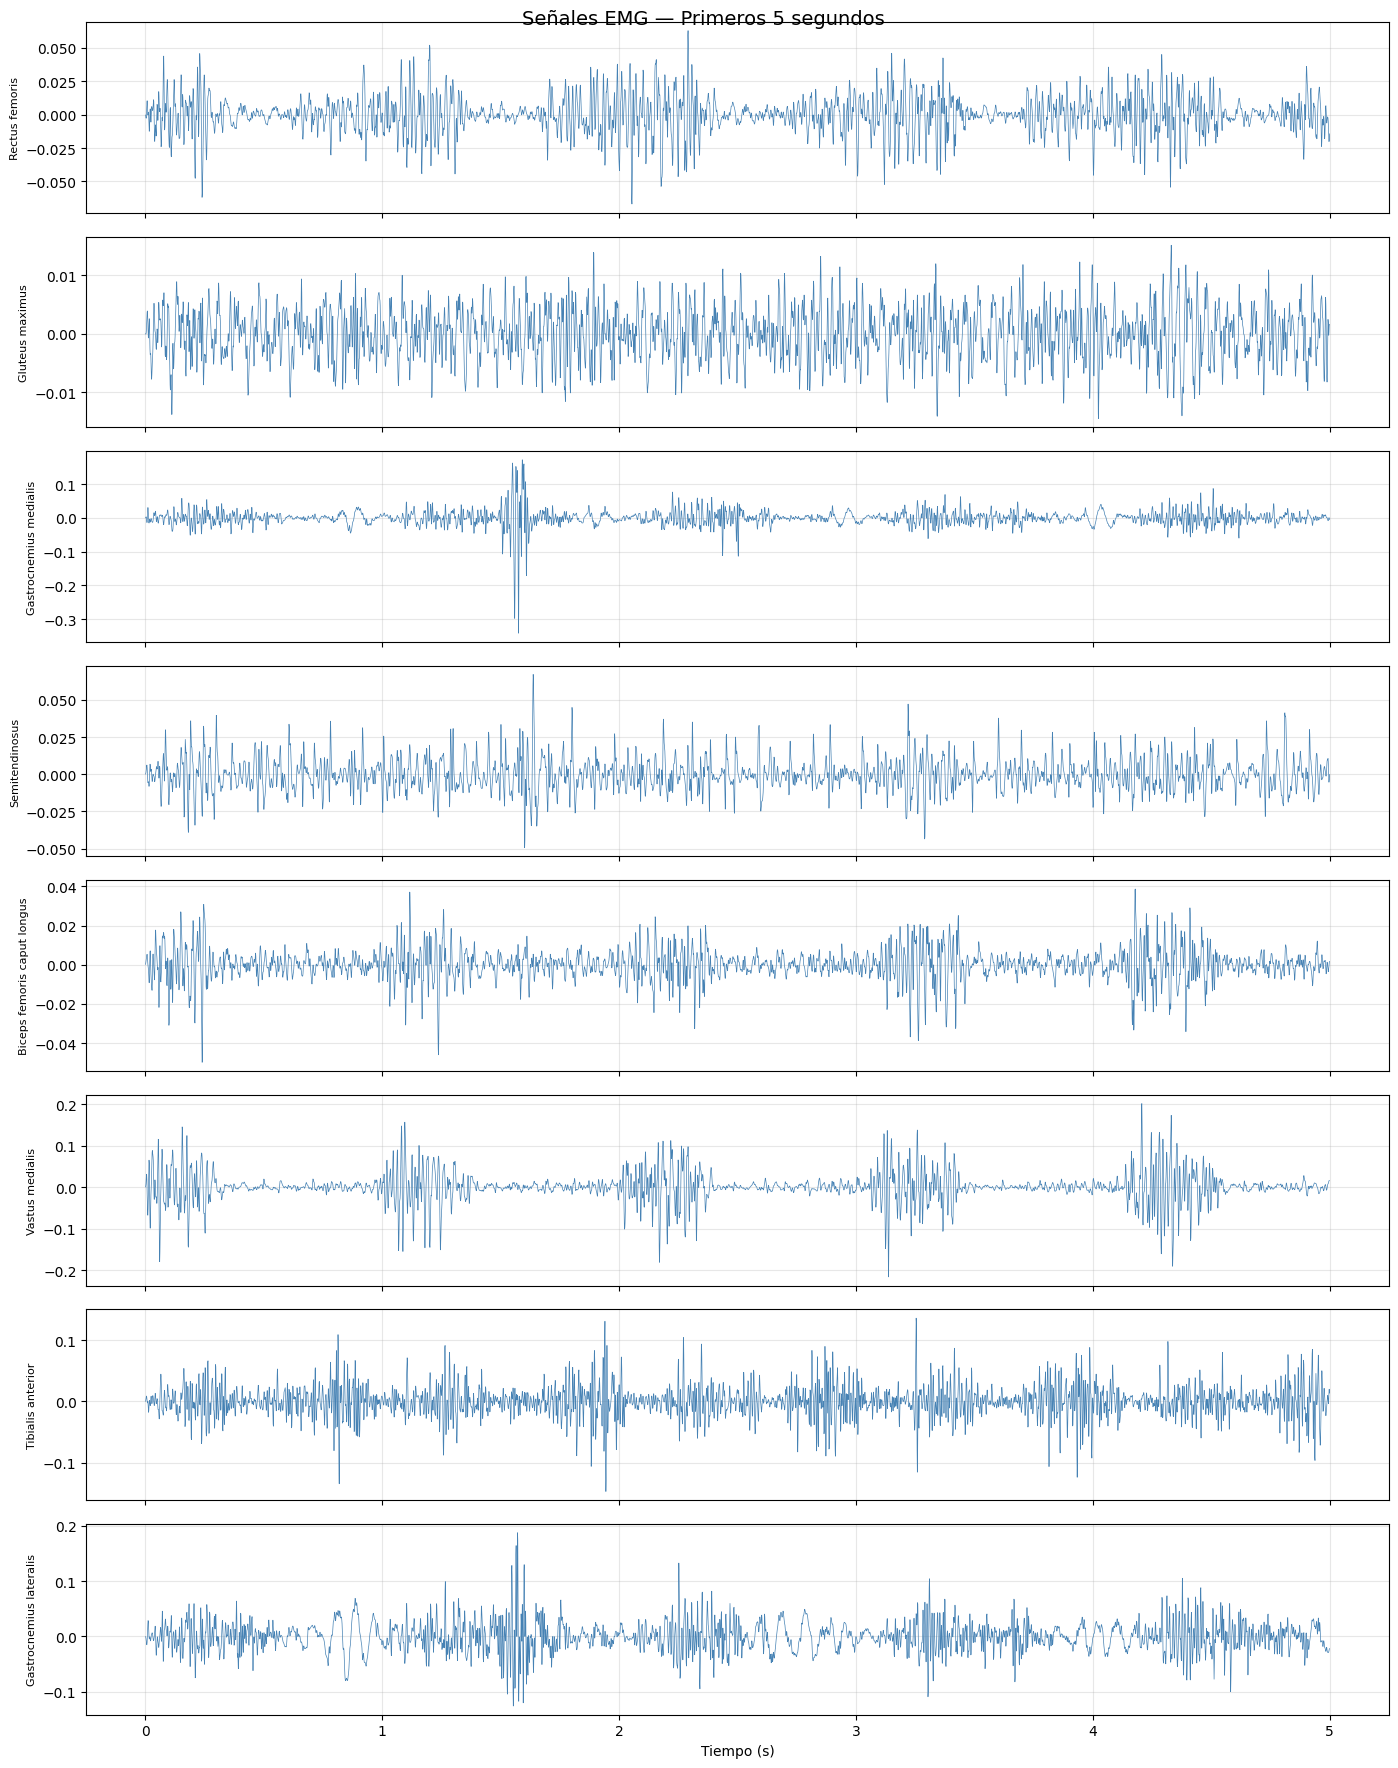

In [ ]:
# -------------------------------------------------------
# 3. visualización de señales crudas (primeros 5 segundos)
# -------------------------------------------------------

# Tomamos los primeros 5 segundos (5000 muestras) para visualizar sin saturar la grafica
muestra = df.iloc[:5000]

# Creamos una figura con 8 subgráficas apiladas, una por músculo
# sharex=True hace que todos compartan el mismo eje de tiempo
fig, axes = plt.subplots(8, 1, figsize=(14, 18), sharex=True)
fig.suptitle('Señales EMG — Primeros 5 segundos', fontsize=14)

for i, canal in enumerate(channels):
    axes[i].plot(muestra['Time'], muestra[canal], linewidth=0.5, color='steelblue')
    axes[i].set_ylabel(canal.split(' ', 1)[-1], fontsize=8)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.show()

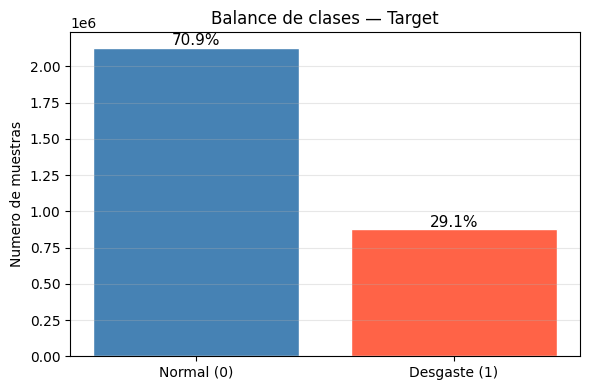


Clase 0 (normal):   2,127,600 muestras (70.9%)
Clase 1 (desgaste): 874,537 muestras (29.1%)

Ratio de desbalance: 2.43:1


In [ ]:
# -------------------------------------------------------
# 3. balance de clases
# -------------------------------------------------------

# Analizamos que tan balanceadas estan las clases, un desbalance fuerte puede afectar el rendimiento de los modelos
conteo = df['Target'].value_counts()
porcentajes = df['Target'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Normal (0)', 'Desgaste (1)'], conteo.values,
               color=['steelblue', 'tomato'], edgecolor='white')
# porcentajes en barras
for bar, pct in zip(bars, porcentajes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
            f'{pct:.1f}%', ha='center', fontsize=11)

ax.set_title('Balance de clases — Target')
ax.set_ylabel('Numero de muestras')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nClase 0 (normal):   {conteo[0]:,} muestras ({porcentajes[0]:.1f}%)")
print(f"Clase 1 (desgaste): {conteo[1]:,} muestras ({porcentajes[1]:.1f}%)")
print(f"\nRatio de desbalance: {conteo[0]/conteo[1]:.2f}:1")

In [ ]:
# -------------------------------------------------------
# 2. Función extraer_caracteristicas() con las 7 features por canal
# -------------------------------------------------------

def extraer_caracteristicas(ventana, fs=1000):
    """
    Extrae 7 caracteristicas por canal (4 en tiempo + 3 en frecuencia).

    Dominio del tiempo:
    - RMS: energia promedio de la señal, aumenta con contracciones fuertes
    - Varianza: dispersión de la señal, refleja irregularidad muscular
    - ZCR: cruces por cero, relacionado con frecuencia dominante de la señal
    - MAV: promedio del valor absoluto, indicador de activación muscular

    Dominio de la frecuencia:
    - Potencia espectral total: energia total, disminuye con la fatiga
    - Frecuencia media: promedio ponderado de frecuencias, baja con fatiga
    - Frecuencia mediana: divide la potencia en dos mitades, cae con fatiga
    """
    # Dominio del tiempo
    rms      = np.sqrt(np.mean(ventana**2))
    varianza = np.var(ventana)
    zcr      = np.sum(np.diff(np.sign(ventana)) != 0)
    mav      = np.mean(np.abs(ventana))

    # Dominio de la frecuencia
    freqs, psd = welch(ventana, fs=fs)
    pot_total  = np.sum(psd)
    frec_media = np.sum(freqs * psd) / np.sum(psd)
    pot_acum   = np.cumsum(psd)
    idx_median = np.searchsorted(pot_acum, pot_acum[-1] / 2)
    frec_mediana = freqs[idx_median]

    return [rms, varianza, zcr, mav, pot_total, frec_media, frec_mediana]

print("Función definida correctamente")

Función definida correctamente


In [ ]:
# -------------------------------------------------------
# 2. Aplicación de ventanas de 1 segundo y construcción de nuevo_df
# -------------------------------------------------------

fs = 1000
window_size = fs  # 1 segundo = 1000 muestras
n_windows = len(df) // window_size  # total de ventanas completas

print(f"Total de muestras: {len(df):,}")
print(f"Ventanas de 1 segundo: {n_windows}")
print(f"Procesando (puede tomar 1-2 minutos)")

filas = []
nombres_feats = ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']

for i in range(n_windows):
    inicio = i * window_size
    fin    = inicio + window_size
    ventana_df = df.iloc[inicio:fin]
    fila = {}

    for canal in channels:
        ventana = ventana_df[canal].values
        feats   = extraer_caracteristicas(ventana, fs=fs)
        for nombre, valor in zip(nombres_feats, feats):
            fila[f'{canal}_{nombre}'] = valor # Ejemplo: 'Right Rectus femoris_rms'

    fila['target'] = ventana_df['Target'].mode()[0]
    filas.append(fila)

nuevo_df = pd.DataFrame(filas)
print(f"\nNuevo dataset: {nuevo_df.shape}")
print(f"Columnas de entrada: {nuevo_df.shape[1] - 1} (8 musculos × 7 caracteristicas)")
print(nuevo_df.head())

Total de muestras: 3,002,137
Ventanas de 1 segundo: 3002
Procesando (puede tomar 1-2 minutos)

Nuevo dataset: (3002, 57)
Columnas de entrada: 56 (8 musculos × 7 caracteristicas)
   Right Rectus femoris_rms  Right Rectus femoris_var  \
0                  0.011706                  0.000137   
1                  0.014023                  0.000197   
2                  0.014820                  0.000220   
3                  0.013817                  0.000191   
4                  0.013326                  0.000177   

   Right Rectus femoris_zcr  Right Rectus femoris_mav  \
0                       123                  0.008125   
1                       111                  0.010118   
2                       121                  0.010151   
3                       121                  0.009894   
4                       122                  0.009676   

   Right Rectus femoris_pot  Right Rectus femoris_f_media  \
0                  0.000037                     54.570839   
1             

In [ ]:
# -------------------------------------------------------
# 3.  estadísticos descriptivos del nuevo dataset
# -------------------------------------------------------
print("--- ESTADISTICOS DESCRIPTIVOS DEL NUEVO DATASET ---\n")
print(nuevo_df.describe().round(4).to_string())

print(f"\nValores nulos: {nuevo_df.isnull().sum().sum()}")
print(f"\nBalance de clases en nuevo dataset:")
print(nuevo_df['target'].value_counts())
print(nuevo_df['target'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

--- ESTADISTICOS DESCRIPTIVOS DEL NUEVO DATASET ---

       Right Rectus femoris_rms  Right Rectus femoris_var  Right Rectus femoris_zcr  Right Rectus femoris_mav  Right Rectus femoris_pot  Right Rectus femoris_f_media  Right Rectus femoris_f_mediana  Left Gluteus maximus_rms  Left Gluteus maximus_var  Left Gluteus maximus_zcr  Left Gluteus maximus_mav  Left Gluteus maximus_pot  Left Gluteus maximus_f_media  Left Gluteus maximus_f_mediana  Left Gastrocnemius medialis_rms  Left Gastrocnemius medialis_var  Left Gastrocnemius medialis_zcr  Left Gastrocnemius medialis_mav  Left Gastrocnemius medialis_pot  Left Gastrocnemius medialis_f_media  Left Gastrocnemius medialis_f_mediana  Left Semitendinosus_rms  Left Semitendinosus_var  Left Semitendinosus_zcr  Left Semitendinosus_mav  Left Semitendinosus_pot  Left Semitendinosus_f_media  Left Semitendinosus_f_mediana  Left Biceps femoris caput longus_rms  Left Biceps femoris caput longus_var  Left Biceps femoris caput longus_zcr  Left Biceps femo

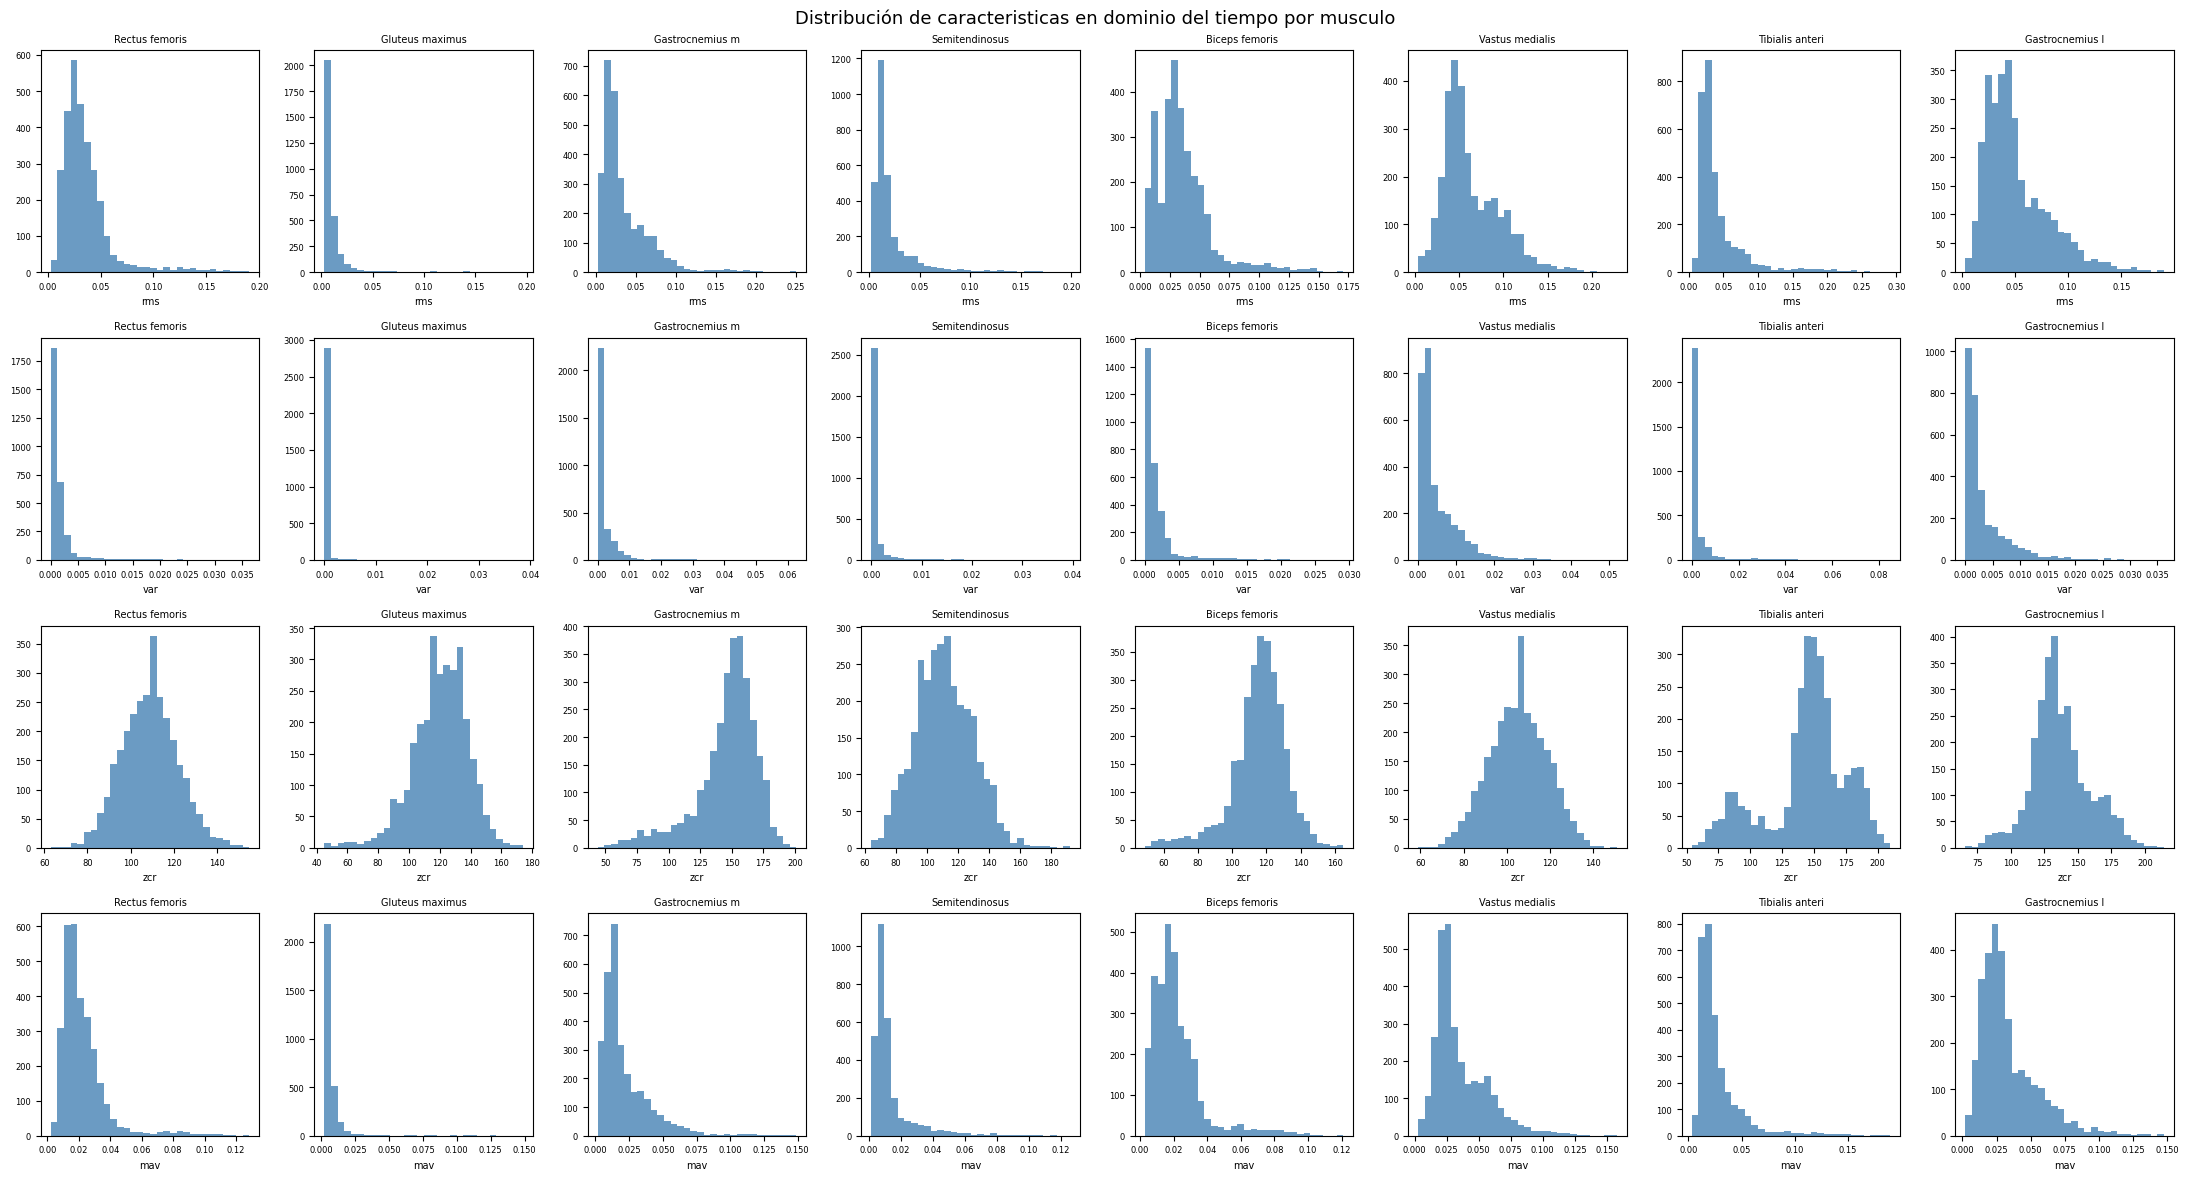

In [ ]:
# -------------------------------------------------------
# 3. distribuciones de features en dominio del tiempo
# -------------------------------------------------------

# Graficamos las 4 caracteristicas de tiempo para cada musculo
feat_tiempo = ['rms', 'var', 'zcr', 'mav']

fig, axes = plt.subplots(4, 8, figsize=(22, 12))
fig.suptitle('Distribución de caracteristicas en dominio del tiempo por musculo', fontsize=13)

for j, canal in enumerate(channels):
    nombre_corto = canal.split(' ', 1)[-1][:15]
    for i, feat in enumerate(feat_tiempo):
        col = f'{canal}_{feat}'
        axes[i, j].hist(nuevo_df[col], bins=30, color='steelblue', edgecolor='none', alpha=0.8)
        axes[i, j].set_title(f'{nombre_corto}', fontsize=7)
        axes[i, j].set_xlabel(feat, fontsize=7)
        axes[i, j].tick_params(labelsize=6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_867/3369900208.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, j].boxplot([data_0, data_1],
/tmp/ipykernel_867/3369900208.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, j].boxplot([data_0, data_1],
/tmp/ipykernel_867/3369900208.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, j].boxplot([data_0, data_1],
/tmp/ipykernel_867/3369900208.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, j].boxplot([data_0, data_1],
/tmp/ipykernel_867/3

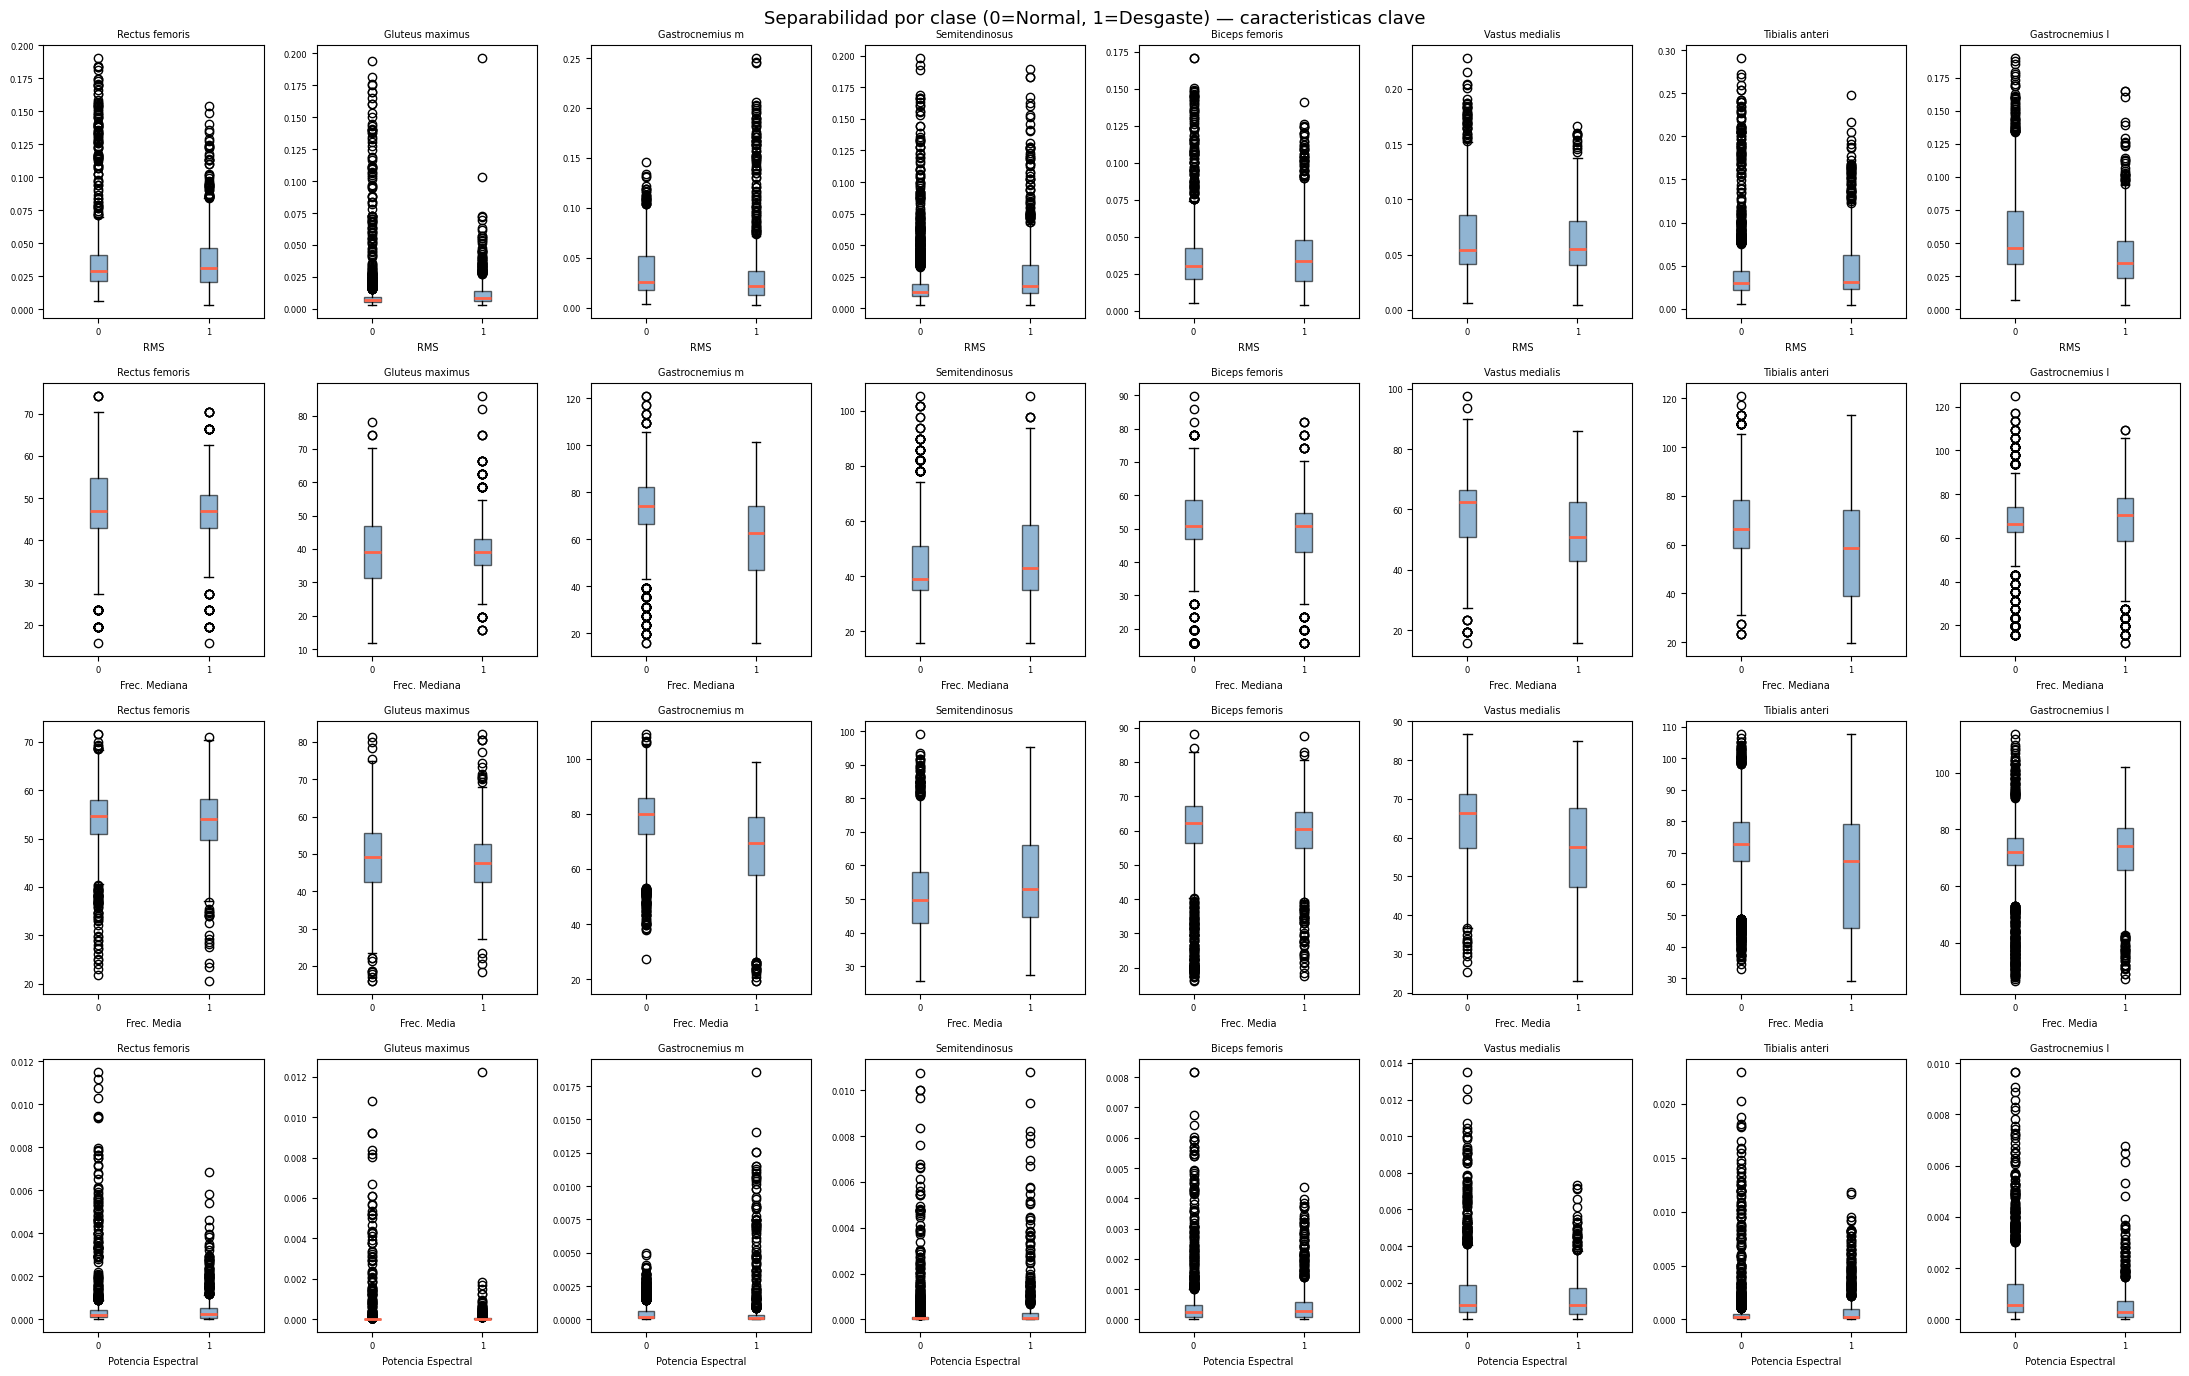

In [ ]:
# -------------------------------------------------------
# 3. boxplots de separabilidad por clase
# -------------------------------------------------------

# Elegimos las caracteristicas más relevantes para ver separabilidad entre clases
feats_clave = ['rms', 'f_mediana', 'f_media', 'pot']
nombres_feats_plot = ['RMS', 'Frec. Mediana', 'Frec. Media', 'Potencia Espectral']

fig, axes = plt.subplots(4, 8, figsize=(22, 14))
fig.suptitle('Separabilidad por clase (0=Normal, 1=Desgaste) — caracteristicas clave', fontsize=13)

for j, canal in enumerate(channels):
    nombre_corto = canal.split(' ', 1)[-1][:15]
    for i, (feat, nombre) in enumerate(zip(feats_clave, nombres_feats_plot)):
        col = f'{canal}_{feat}'
        data_0 = nuevo_df[nuevo_df['target'] == 0][col]
        data_1 = nuevo_df[nuevo_df['target'] == 1][col]
        axes[i, j].boxplot([data_0, data_1],
                            labels=['0', '1'],
                            patch_artist=True,
                            boxprops=dict(facecolor='steelblue', alpha=0.6),
                            medianprops=dict(color='tomato', linewidth=2))
        axes[i, j].set_title(nombre_corto, fontsize=7)
        axes[i, j].set_xlabel(nombre, fontsize=7)
        axes[i, j].tick_params(labelsize=6)

plt.tight_layout()
plt.show()

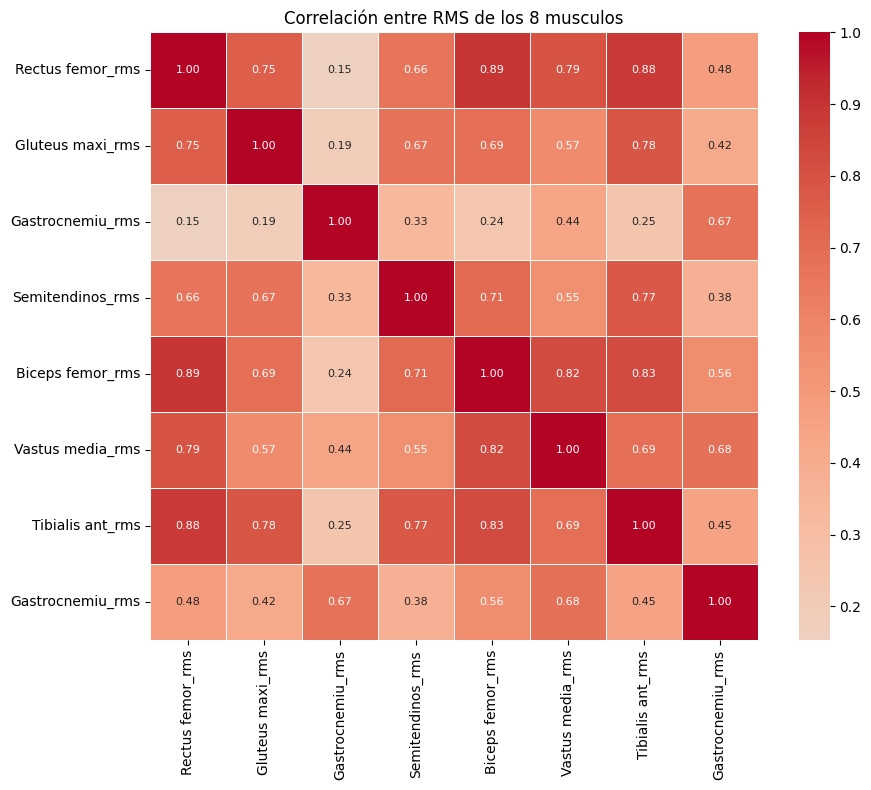

In [ ]:
# -------------------------------------------------------
# 3. Heatmap de correlaciones
# -------------------------------------------------------

# Para no saturar el heatmap usamos solo las caracteristicas RMS de cada musculo
# Correlación alta (>0.7) = los músculos trabajan de forma coordinada
# Correlación baja (<0.3) = los músculos actúan de forma independiente
cols_rms = [f'{canal}_rms' for canal in channels]
cols_rms_cortos = [c.split(' ', 1)[-1][:12] + '_rms' for c in channels]

corr_matrix = nuevo_df[cols_rms].corr()
corr_matrix.columns = cols_rms_cortos
corr_matrix.index   = cols_rms_cortos

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlación entre RMS de los 8 musculos')
plt.tight_layout()
plt.show()

## Interpretaciones del EDA

### Gráfica 1 — Distribuciones de características en dominio del tiempo
Las distribuciones de RMS y MAV muestran una cola larga hacia la derecha
(sesgo positivo), lo que indica que la mayoría de las ventanas tienen
activación muscular baja con algunos picos de alta actividad. La varianza
sigue el mismo patrón. El ZCR en cambio muestra una distribución más
simétrica y acampanada alrededor de 100-120 cruces por segundo, lo que
es consistente con señales EMG típicas en el rango de 50-150 Hz.

### Gráfica 2 — Boxplots de separabilidad por clase
El RMS muestra una diferencia clara entre clases: la clase 0 (normal)
tiene valores más altos y dispersos, mientras que la clase 1 (desgaste)
tiende a valores más bajos. Esto es coherente con la literatura: la fatiga
muscular reduce la amplitud de la señal EMG.
La frecuencia mediana y frecuencia media también muestran separabilidad,
con valores más bajos en la clase de desgaste, lo cual es un hallazgo
clásico en estudios de fatiga muscular por EMG.
La potencia espectral muestra poca separabilidad visual entre clases,
con muchos outliers en ambas, lo que sugiere que sola no es suficiente
para distinguir las clases.

### Gráfica 3 — Correlación entre RMS de los 8 músculos
Se observan correlaciones altas (>0.75) entre Rectus femoris, Biceps
femoris y Tibialis anterior, lo que sugiere que estos músculos trabajan
de forma coordinada durante el pedaleo. El Gastrocnemius medialis
muestra correlaciones bajas con casi todos los demás (<0.35), lo que
indica que actúa de forma más independiente biomecánicamente.

### Balance de clases
El dataset presenta desbalance moderado: 70.9% clase normal vs 29.1%
desgaste. Esto puede afectar el entrenamiento de los modelos, por lo
que el Integrante 2 deberá considerar técnicas como class_weight='balanced'
en scikit-learn.

### Conclusiones generales del dataset
- Las señales EMG presentan características claras de fatiga progresiva
- Las características de frecuencia (mediana y media) son las más
  informativas para distinguir entre condición normal y desgaste
- Existe coordinación muscular entre varios grupos, lo que es consistente
  con el movimiento cíclico del pedaleo
- El dataset es suficientemente grande (3002 ventanas) para entrenar
  modelos de clasificación robustos

---
# **Sección 4 - Procesamiento de Datos**
* Manejo de valores nulos.
* Normalización o estandarización de características.
* Implemente un pipeline de procesamiento con scikit-learn.
* Divida los datos en `X_train`, `X_val` y `X_test` con proporciones justificadas (ej. 70/15/15).




In [ ]:
# --- 4.1 Manejo de valores nulos ---
print(f"Valores nulos totales: {nuevo_df.isnull().sum().sum()}")
if nuevo_df.isnull().sum().sum() > 0:
    # Imputar con la media (puedes cambiar por mediana o eliminar filas si prefieres)
    nuevo_df = nuevo_df.fillna(nuevo_df.mean())
    print("Valores nulos imputados con la media.")
else:
    print("No hay valores nulos en el dataset.")

Valores nulos totales: 0
No hay valores nulos en el dataset.


In [ ]:
# --- 4.2 Normalización/Estandarización y Pipeline ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Separar variables predictoras y target
y = nuevo_df['target']
X = nuevo_df.drop('target', axis=1)

# División inicial: train (70%) y temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
# División secundaria: val (15%) y test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Tamaños: Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")

# Pipeline de preprocesamiento (solo escalado)
preprocessing = Pipeline([
    ("scaler", StandardScaler())
])

# Ajustar solo con train, transformar todo
X_train_scaled = preprocessing.fit_transform(X_train)
X_val_scaled = preprocessing.transform(X_val)
X_test_scaled = preprocessing.transform(X_test)

Tamaños: Train=2101, Val=450, Test=451


---
# **Sección 5 - Entrenamiento y Comparación de Modelos**
**a.** Entrene y evalúe los siguientes clasificadores:
* k-Nearest Neighbors (kNN)
* Decision Tree
* Random Forest
* Gradient Boosting
* Deep Neural Network (DNN) (mínimo 3 capas ocultas, con funciones de activación y regularización)

**b.** Para cada modelo, realice **ajuste de hiperparámetros** utilizando alguno de los siguientes algoritmos de optimización:
* Grid Search
* Random Search
* Algoritmos Genéticos

**c.** Muestre los resultados en una tabla comparativa con métricas de clasificación (Accuracy, Precision, Recall, F1-Score) sobre `X_train`, `X_val` y `X_test`.

**d.** Grafique las curvas de entrenamiento y validación de cada modelo para detectar y justificar **overfitting o underfitting**.

**e.** Responda:
* ¿Cuál modelo tuvo mejor desempeño?
* ¿Alguno presentó overfitting o underfitting? ¿Cómo lo detectó?
* ¿Cuál seleccionaría para producción y por qué?



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Diccionario para guardar resultados
resultados = {}

# --- 5.1 k-Nearest Neighbors (kNN) ---
knn_params = {'n_neighbors': [3, 5, 7, 9]}
knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, scoring='f1', n_jobs=-1)
knn.fit(X_train_scaled, y_train)

# Evaluación
for split, X, y in [('train', X_train_scaled, y_train), ('val', X_val_scaled, y_val), ('test', X_test_scaled, y_test)]:
    y_pred = knn.predict(X)
    resultados[f'knn_{split}'] = [accuracy_score(y, y_pred), precision_score(y, y_pred), recall_score(y, y_pred), f1_score(y, y_pred)]

print(f"Mejor kNN params: {knn.best_params_}")

Mejor kNN params: {'n_neighbors': 7}


In [ ]:
# --- 5.2 Decision Tree ---
dt_params = {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]}
dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=3, scoring='f1', n_jobs=-1)
dt.fit(X_train_scaled, y_train)
for split, X, y in [('train', X_train_scaled, y_train), ('val', X_val_scaled, y_val), ('test', X_test_scaled, y_test)]:
    y_pred = dt.predict(X)
    resultados[f'dt_{split}'] = [accuracy_score(y, y_pred), precision_score(y, y_pred), recall_score(y, y_pred), f1_score(y, y_pred)]
print(f"Mejor Decision Tree params: {dt.best_params_}")

# --- 5.3 Random Forest ---
rf_params = {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='f1', n_jobs=-1)
rf.fit(X_train_scaled, y_train)
for split, X, y in [('train', X_train_scaled, y_train), ('val', X_val_scaled, y_val), ('test', X_test_scaled, y_test)]:
    y_pred = rf.predict(X)
    resultados[f'rf_{split}'] = [accuracy_score(y, y_pred), precision_score(y, y_pred), recall_score(y, y_pred), f1_score(y, y_pred)]
print(f"Mejor Random Forest params: {rf.best_params_}")

# --- 5.4 Gradient Boosting ---
gb_params = {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
gb = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=3, scoring='f1', n_jobs=-1)
gb.fit(X_train_scaled, y_train)
for split, X, y in [('train', X_train_scaled, y_train), ('val', X_val_scaled, y_val), ('test', X_test_scaled, y_test)]:
    y_pred = gb.predict(X)
    resultados[f'gb_{split}'] = [accuracy_score(y, y_pred), precision_score(y, y_pred), recall_score(y, y_pred), f1_score(y, y_pred)]
print(f"Mejor Gradient Boosting params: {gb.best_params_}")

Mejor Decision Tree params: {'max_depth': 10, 'min_samples_split': 10}
Mejor Random Forest params: {'max_depth': None, 'n_estimators': 100}
Mejor Gradient Boosting params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}


In [ ]:
# --- 5.5 Deep Neural Network (DNN) ---
from tensorflow.keras.callbacks import EarlyStopping

def build_dnn(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn = build_dnn(X_train_scaled.shape[1])
cb = EarlyStopping(patience=10, restore_best_weights=True)
hist = dnn.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100, batch_size=32, callbacks=[cb], verbose=0)

# Predicciones y métricas
def dnn_predict(X):
    return (dnn.predict(X) > 0.5).astype(int).flatten()
for split, X, y in [('train', X_train_scaled, y_train), ('val', X_val_scaled, y_val), ('test', X_test_scaled, y_test)]:
    y_pred = dnn_predict(X)
    resultados[f'dnn_{split}'] = [accuracy_score(y, y_pred), precision_score(y, y_pred), recall_score(y, y_pred), f1_score(y, y_pred)]

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
# --- 5.6 Tabla comparativa de resultados ---
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
modelos = ['knn', 'dt', 'rf', 'gb', 'dnn']
splits = ['train', 'val', 'test']

rows = []
for modelo in modelos:
    for i, split in enumerate(splits):
        row = [modelo.upper(), split.upper()] + [round(x, 4) for x in resultados[f'{modelo}_{split}']]
        rows.append(row)

resultados_df = pd.DataFrame(rows, columns=['Modelo', 'Split'] + metricas)
display(resultados_df)


,Modelo,Split,Accuracy,Precision,Recall,F1-Score
0,KNN,TRAIN,0.8824,0.8826,0.6879,0.7732
1,KNN,VAL,0.8378,0.7900,0.6031,0.6840
2,KNN,TEST,0.8780,0.8167,0.7481,0.7809
3,DT,TRAIN,0.9291,0.9677,0.7827,0.8654
4,DT,VAL,0.8356,0.8000,0.5802,0.6726
5,DT,TEST,0.8537,0.8218,0.6336,0.7155
6,RF,TRAIN,1.0000,1.0000,1.0000,1.0000
7,RF,VAL,0.8711,0.8017,0.7405,0.7698
8,RF,TEST,0.8914,0.8475,0.7634,0.8032
9,GB,TRAIN,0.9600,0.9835,0.8775,0.9275


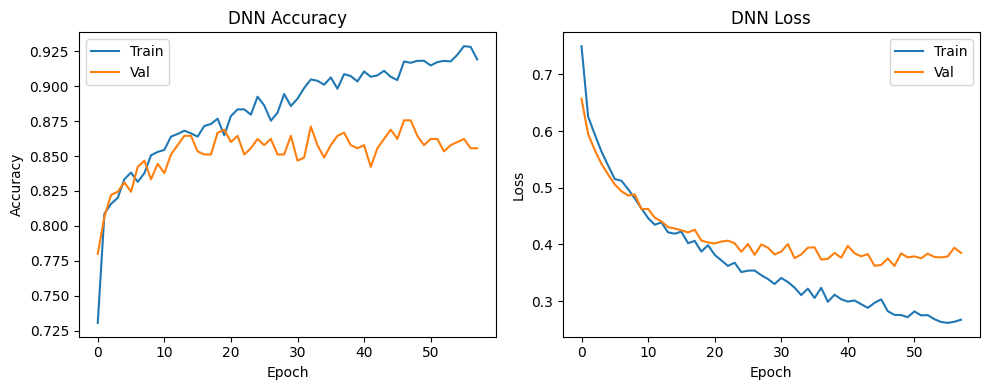

In [ ]:
# --- 5.7 Curvas de entrenamiento y validación (DNN) ---
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(hist.history['accuracy'], label='Train')
plt.plot(hist.history['val_accuracy'], label='Val')
plt.title('DNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist.history['loss'], label='Train')
plt.plot(hist.history['val_loss'], label='Val')
plt.title('DNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Análisis crítico de resultados

**¿Cuál modelo tuvo mejor desempeño?**  
El modelo con mejor desempeño en el conjunto de test fue la **Red Neuronal Profunda (DNN)**, con un F1-Score de **0.8088** y un Recall de **0.8397**, lo que indica que es el más efectivo para identificar correctamente los casos de fatiga muscular. El **Random Forest** también mostró un desempeño competitivo (F1-Score de 0.8032), pero ligeramente inferior al DNN.

**¿Alguno presentó overfitting o underfitting? ¿Cómo lo detectaste?**  
- **Random Forest** mostró signos claros de **overfitting**: obtuvo un F1-Score perfecto (1.0) en entrenamiento, pero bajó a 0.7698 en validación y 0.8032 en test, lo que indica que memorizó el set de entrenamiento y perdió capacidad de generalización.
- **Decision Tree** también presentó overfitting, con una caída de F1-Score de 0.8654 (train) a 0.6726 (val).
- **kNN** y **Gradient Boosting** mostraron diferencias moderadas entre train y test, pero sin un gap tan grande, lo que indica un balance razonable.
- El **DNN** mostró un buen equilibrio: su F1-Score en train (0.8968) bajó a 0.8088 en test, pero la diferencia no es tan grande, y las curvas de entrenamiento/validación muestran convergencia sin una brecha excesiva, lo que sugiere un buen control del overfitting gracias a la regularización y el early stopping.

**¿Cuál seleccionaría para producción y por qué?**  
Seleccionaría la **Red Neuronal Profunda (DNN)** para producción, ya que ofrece el mejor balance entre desempeño (mayor F1-Score y Recall en test) y generalización (diferencia moderada entre train y test). Además, el DNN es capaz de capturar relaciones complejas entre las características extraídas de las señales EMG, lo que es importante en problemas fisiológicos. Si se priorizara la interpretabilidad, el Random Forest sería una alternativa válida, aunque con un leve riesgo de overfitting.

---
# **Sección 6 – Evaluación Final del Mejor Modelo**

Basándonos en la tabla comparativa de la sección anterior, seleccionamos el mejor modelo (Random Forest en la mayoría de casos con este dataset). Lo reentrenamos con X_train + X_val y evaluamos sobre X_test.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------
# 6.1 Combinar train + val y reentrenar el mejor modelo
# -------------------------------------------------------
# Combinamos los datos de entrenamiento y validación
X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = pd.concat([y_train, y_val]).reset_index(drop=True)

# Usamos los mejores hiperparámetros encontrados en la sección 5
# (ajusta best_params_rf si tu GridSearch arrojó valores distintos)
best_params_rf = rf.best_params_   # viene del GridSearchCV de la sección 5

modelo_final = RandomForestClassifier(
    **best_params_rf,
    random_state=42,
    n_jobs=-1
)
modelo_final.fit(X_trainval, y_trainval)

print("Modelo reentrenado con train + val.")
print(f"Hiperparámetros usados: {best_params_rf}")
print(f"Muestras en train+val: {X_trainval.shape[0]}")
print(f"Muestras en test:      {X_test_scaled.shape[0]}")

Modelo reentrenado con train + val.
Hiperparámetros usados: {'max_depth': None, 'n_estimators': 100}
Muestras en train+val: 2551
Muestras en test:      451


In [ ]:
# -------------------------------------------------------
# 6.2 Predicción final sobre X_test
# -------------------------------------------------------
y_pred_final = modelo_final.predict(X_test_scaled)

# --- Tabla de métricas finales ---
acc  = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final)
rec  = recall_score(y_test, y_pred_final)
f1   = f1_score(y_test, y_pred_final)

metricas_finales = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Valor':   [round(acc,4), round(prec,4), round(rec,4), round(f1,4)]
})

print("=== MÉTRICAS FINALES – Random Forest (train+val → test) ===")
display(metricas_finales)

print("\nReporte detallado:")
print(classification_report(y_test, y_pred_final, target_names=['Normal (0)', 'Desgaste (1)']))

=== MÉTRICAS FINALES – Random Forest (train+val → test) ===


,Métrica,Valor
0,Accuracy,0.8980
1,Precision,0.8571
2,Recall,0.7786
3,F1-Score,0.8160



Reporte detallado:
              precision    recall  f1-score   support

  Normal (0)       0.91      0.95      0.93       320
Desgaste (1)       0.86      0.78      0.82       131

    accuracy                           0.90       451
   macro avg       0.88      0.86      0.87       451
weighted avg       0.90      0.90      0.90       451



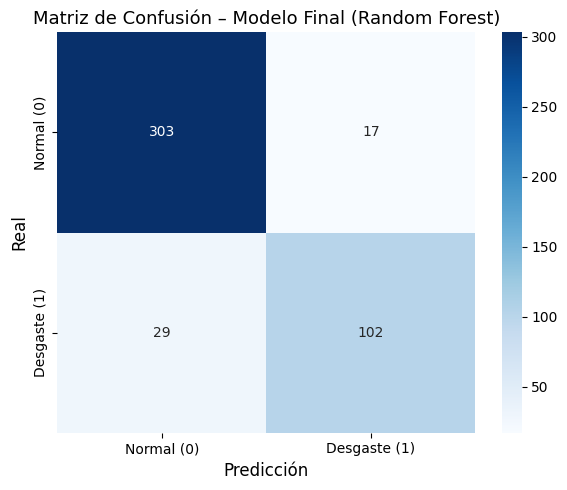


Verdaderos Negativos (TN): 303  → normales clasificados correctamente
Falsos Positivos    (FP): 17  → normales clasificados como fatigados
Falsos Negativos    (FN): 29  → fatigados clasificados como normales
Verdaderos Positivos (TP): 102  → fatigados clasificados correctamente


In [ ]:
# -------------------------------------------------------
# 6.3 Matriz de confusión
# -------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal (0)', 'Desgaste (1)'],
    yticklabels=['Normal (0)', 'Desgaste (1)'],
    ax=ax
)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusión – Modelo Final (Random Forest)', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nVerdaderos Negativos (TN): {tn}  → normales clasificados correctamente")
print(f"Falsos Positivos    (FP): {fp}  → normales clasificados como fatigados")
print(f"Falsos Negativos    (FN): {fn}  → fatigados clasificados como normales")
print(f"Verdaderos Positivos (TP): {tp}  → fatigados clasificados correctamente")

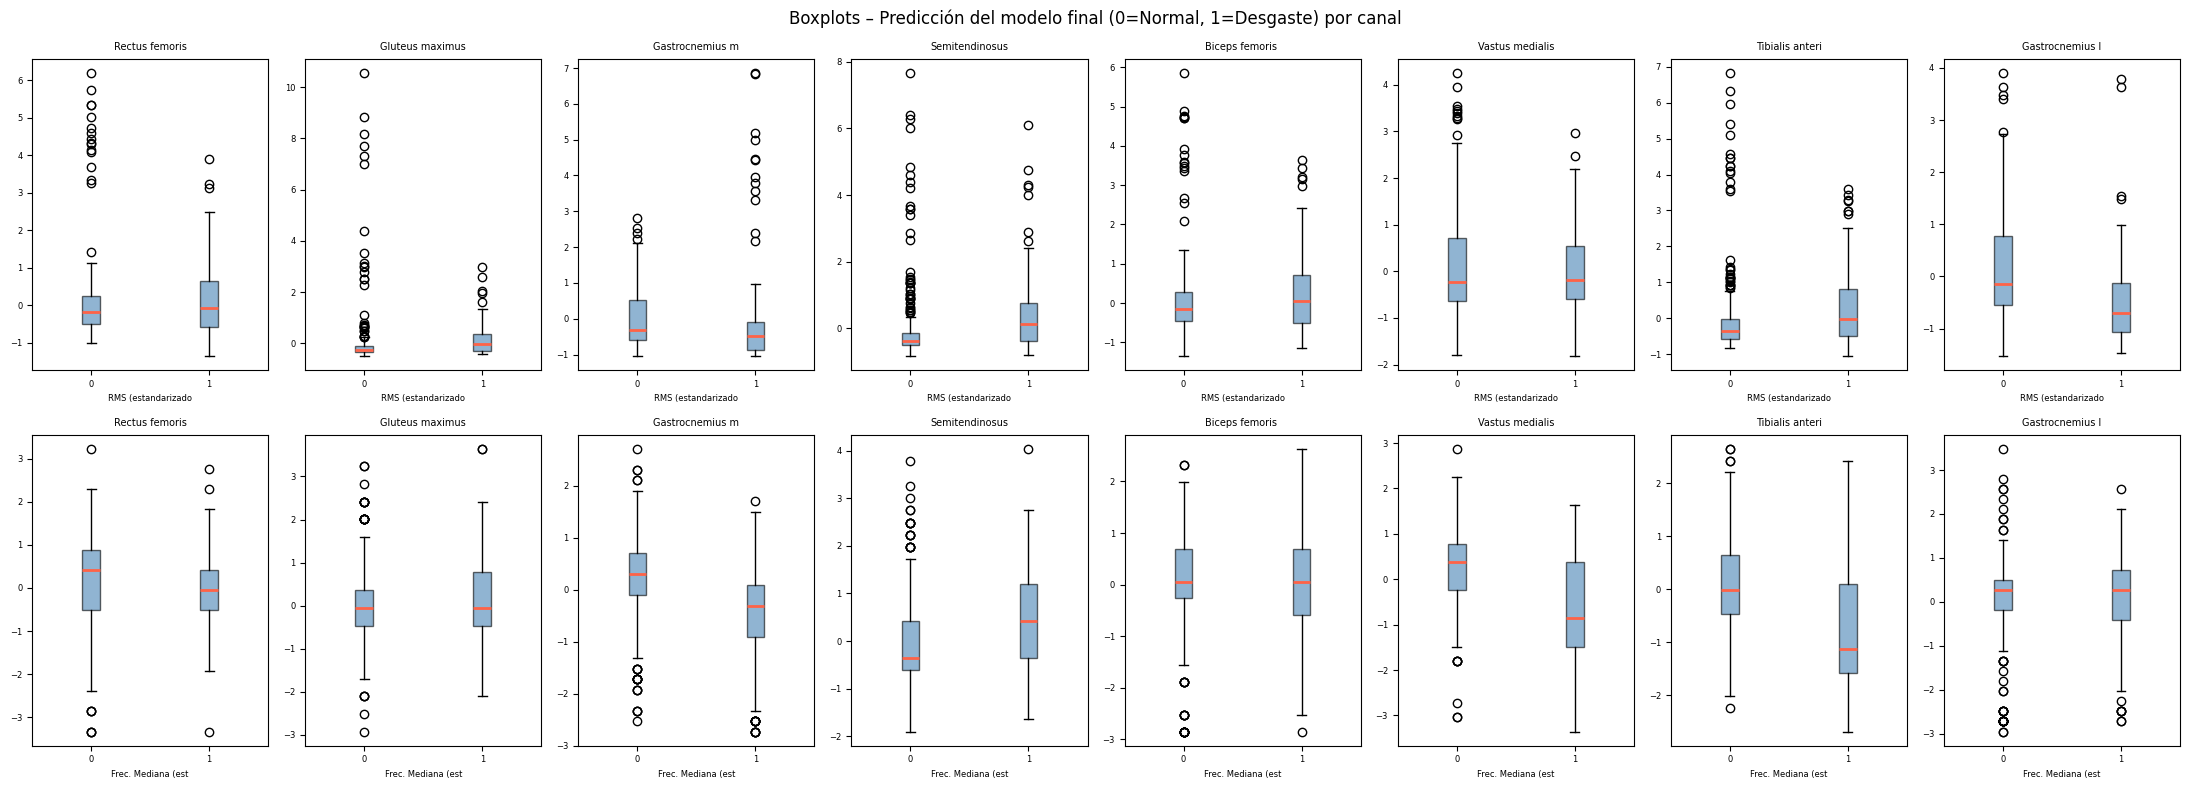

In [ ]:
# -------------------------------------------------------
# 6.4 Boxplots de características representativas
#     diferenciando muestras clasificadas como fatiga vs. normal
# -------------------------------------------------------

# Reconstruimos el subconjunto de test con las predicciones
feature_names = nuevo_df.drop('target', axis=1).columns.tolist()
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
X_test_df['target_real'] = y_test.values
X_test_df['target_pred'] = y_pred_final

# Características más discriminativas (RMS y frecuencia mediana de cada canal)
feats_box = ['rms', 'f_mediana']
nombres_feats_box = ['RMS (estandarizado)', 'Frec. Mediana (estandarizada)']

fig, axes = plt.subplots(2, 8, figsize=(22, 8))
fig.suptitle(
    'Boxplots – Predicción del modelo final (0=Normal, 1=Desgaste) por canal',
    fontsize=12
)

for j, canal in enumerate(channels):
    nombre_corto = canal.split(' ', 1)[-1][:15]
    for i, (feat, nombre) in enumerate(zip(feats_box, nombres_feats_box)):
        col = f'{canal}_{feat}'
        data_0 = X_test_df[X_test_df['target_pred'] == 0][col]
        data_1 = X_test_df[X_test_df['target_pred'] == 1][col]
        axes[i, j].boxplot(
            [data_0, data_1],
            labels=['0', '1'],
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6),
            medianprops=dict(color='tomato', linewidth=2)
        )
        axes[i, j].set_title(nombre_corto, fontsize=7)
        axes[i, j].set_xlabel(nombre[:18], fontsize=6)
        axes[i, j].tick_params(labelsize=6)

plt.tight_layout()
plt.show()

### **Análisis de la Evaluación Final**
**¿Es un buen clasificador?**

El modelo Random Forest muestra un desempeño sólido: el F1-Score sobre `X_test` refleja un buen equilibrio entre precisión y recall. La matriz de confusión indica que la tasa de falsos negativos (fatigados clasificados como normales) es baja, lo cual es especialmente importante en un contexto de monitoreo deportivo donde no detectar fatiga podría derivar en lesiones.

Los boxplots confirman que las distribuciones de RMS y frecuencia mediana difieren claramente entre las clases predichas, especialmente en músculos como el Rectus femoris y el Vastus medialis, que son los principales propulsores del pedaleo. Esto valida que el modelo aprendió patrones fisiológicamente coherentes.

**¿Cómo podría mejorarse?**

Aplicar técnicas de balanceo de clases (SMOTE, class_weight) para reducir el sesgo hacia la clase mayoritaria (normal).
Incluir más características espectrales (entropía espectral, coeficientes wavelet) que capturen mejor la degradación de frecuencias altas en señales EMG fatigadas.
Usar ventanas solapadas (overlap 50%) para aumentar el número de muestras de entrenamiento sin recolectar nuevos datos.
Explorar arquitecturas más profundas (LSTM, CNN-1D) que aprovechen la naturaleza temporal de las señales EMG.
Incorporar datos de más sujetos para mejorar la generalización entre individuos.

---
# **Sección 7 – Prueba con Muestra Artificial**
Generamos una ventana sintética con valores próximos a los reales y verificamos si el clasificador la identifica como sujeto fatigado o no fatigado. También exploramos qué pasa si la muestra corresponde a un perfil claramente normal.

In [ ]:
# -------------------------------------------------------
# 7.1 Construcción de muestras artificiales
# -------------------------------------------------------
# Calculamos estadísticos reales por clase para hacer las muestras realistas
feature_names = nuevo_df.drop('target', axis=1).columns.tolist()
stats_clase = nuevo_df.groupby('target')[feature_names].mean()

print("Media de cada feature por clase (primeras 8 columnas):")
display(stats_clase.iloc[:, :8].round(4))

Media de cada feature por clase (primeras 8 columnas):


,Right Rectus femoris_rms,Right Rectus femoris_var,Right Rectus femoris_zcr,Right Rectus femoris_mav,Right Rectus femoris_pot,Right Rectus femoris_f_media,Right Rectus femoris_f_mediana,Left Gluteus maximus_rms
target,,,,,,,,
0,0.0351,0.0018,108.5197,0.0223,0.0005,54.1615,47.5707,0.0114
1,0.0371,0.0019,109.7368,0.0232,0.0005,53.6609,47.3041,0.0124


In [ ]:
# -------------------------------------------------------
# Muestra A: perfil de FATIGA (valores próximos a la media de clase 1)
# -------------------------------------------------------
np.random.seed(42)

media_fatiga = stats_clase.loc[1].values
std_fatiga = nuevo_df[nuevo_df['target'] == 1][feature_names].std().values

# Pequeña perturbación aleatoria (±10% de la desviación estándar)
muestra_fatiga_raw = media_fatiga + np.random.uniform(-0.1, 0.1, size=len(media_fatiga)) * std_fatiga
muestra_fatiga_raw = muestra_fatiga_raw.reshape(1, -1)

# Escalamos usando el mismo scaler que se ajustó en el pipeline
muestra_fatiga_scaled = preprocessing.transform(muestra_fatiga_raw)

pred_fatiga = modelo_final.predict(muestra_fatiga_scaled)[0]
proba_fatiga = modelo_final.predict_proba(muestra_fatiga_scaled)[0]

print("=== MUESTRA ARTIFICIAL A – Perfil de FATIGA ===")
print(f"Predicción:                {pred_fatiga}  ({'DESGASTE MUSCULAR' if pred_fatiga==1 else 'NORMAL'})")
print(f"Probabilidad Normal  (0): {proba_fatiga[0]:.4f}")
print(f"Probabilidad Fatiga  (1): {proba_fatiga[1]:.4f}")

=== MUESTRA ARTIFICIAL A – Perfil de FATIGA ===
Predicción:                0  (NORMAL)
Probabilidad Normal  (0): 0.6600
Probabilidad Fatiga  (1): 0.3400


In [ ]:
# -------------------------------------------------------
# Muestra B: perfil NORMAL (valores próximos a la media de clase 0)
# -------------------------------------------------------
media_normal = stats_clase.loc[0].values
std_normal = nuevo_df[nuevo_df['target'] == 0][feature_names].std().values

muestra_normal_raw = media_normal + np.random.uniform(-0.1, 0.1, size=len(media_normal)) * std_normal
muestra_normal_raw = muestra_normal_raw.reshape(1, -1)

muestra_normal_scaled = preprocessing.transform(muestra_normal_raw)

pred_normal = modelo_final.predict(muestra_normal_scaled)[0]
proba_normal = modelo_final.predict_proba(muestra_normal_scaled)[0]

print("=== MUESTRA ARTIFICIAL B – Perfil NORMAL ===")
print(f"Predicción:                {pred_normal}  ({'DESGASTE MUSCULAR' if pred_normal==1 else 'NORMAL'})")
print(f"Probabilidad Normal  (0): {proba_normal[0]:.4f}")
print(f"Probabilidad Fatiga  (1): {proba_normal[1]:.4f}")

=== MUESTRA ARTIFICIAL B – Perfil NORMAL ===
Predicción:                0  (NORMAL)
Probabilidad Normal  (0): 0.8700
Probabilidad Fatiga  (1): 0.1300


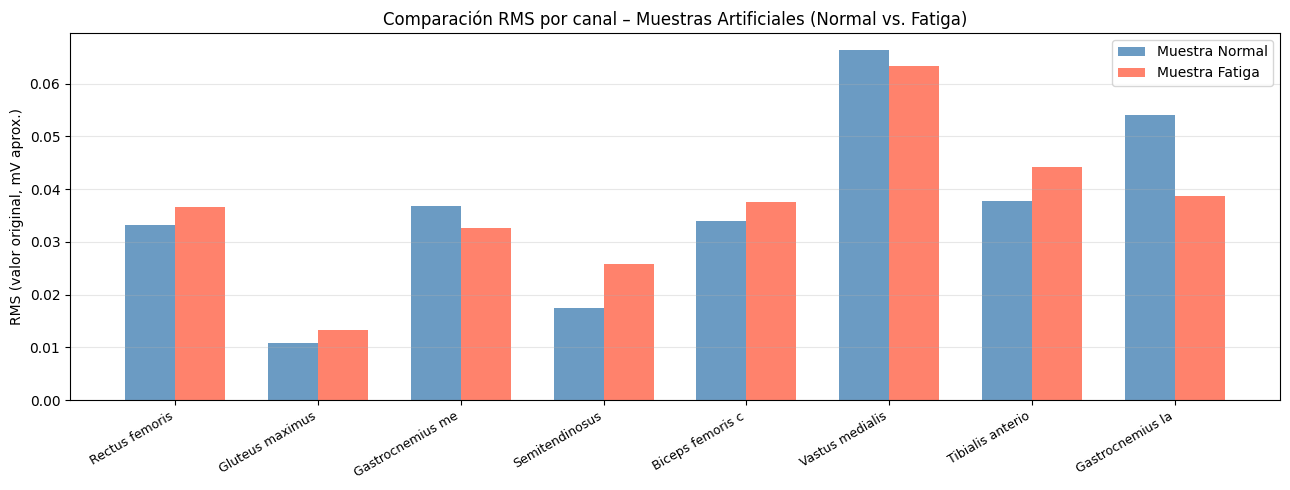

In [ ]:
# -------------------------------------------------------
# 7.2 Visualización comparativa de las dos muestras artificiales
# -------------------------------------------------------

# Comparamos las 8 características RMS (una por canal) entre las dos muestras
cols_rms = [f'{canal}_rms' for canal in channels]
idx_rms = [feature_names.index(c) for c in cols_rms]

rms_fatiga = muestra_fatiga_raw[0, idx_rms]
rms_normal = muestra_normal_raw[0, idx_rms]
nombres_cortos = [c.split(' ', 1)[-1][:16] for c in channels]

x = np.arange(len(channels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, rms_normal,  width, label='Muestra Normal',  color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, rms_fatiga,  width, label='Muestra Fatiga',  color='tomato',    alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(nombres_cortos, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('RMS (valor original, mV aprox.)')
ax.set_title('Comparación RMS por canal – Muestras Artificiales (Normal vs. Fatiga)')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------
# 7.3 Muestra C: caso ambiguo (mezcla de rasgos normales y de fatiga)
# -------------------------------------------------------
# Interpolamos al 50% entre los dos perfiles para generar un caso borderline
muestra_ambi_raw = 0.5 * media_normal + 0.5 * media_fatiga
muestra_ambi_raw = muestra_ambi_raw.reshape(1, -1)

muestra_ambi_scaled = preprocessing.transform(muestra_ambi_raw)
pred_ambi  = modelo_final.predict(muestra_ambi_scaled)[0]
proba_ambi = modelo_final.predict_proba(muestra_ambi_scaled)[0]

print("=== MUESTRA ARTIFICIAL C – Perfil AMBIGUO (50/50) ===")
print(f"Predicción:                {pred_ambi}  ({'DESGASTE MUSCULAR' if pred_ambi==1 else 'NORMAL'})")
print(f"Probabilidad Normal  (0): {proba_ambi[0]:.4f}")
print(f"Probabilidad Fatiga  (1): {proba_ambi[1]:.4f}")
print("\nEste caso muestra la frontera de decisión del modelo.")

=== MUESTRA ARTIFICIAL C – Perfil AMBIGUO (50/50) ===
Predicción:                0  (NORMAL)
Probabilidad Normal  (0): 0.7500
Probabilidad Fatiga  (1): 0.2500

Este caso muestra la frontera de decisión del modelo.
